In [ ]:
# 📍 Étape 0 : Préparation des données
import os
import pandas as pd
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# Définir les chemins dans ton Google Drive
base_path = "/content/drive/MyDrive/CICIoMT2024"
train_path = f"{base_path}/train"
test_path = f"{base_path}/test"
profiling_path = f"{base_path}/profiling"

# Fonction pour charger et taguer les fichiers
def load_and_tag(folder_path, tag):
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    dfs = []
    for file in all_files:
        try:
            df = pd.read_csv(file)
            df["Label"] = os.path.basename(file).replace(".pcap.csv", "").replace("_train", "").replace("_test", "")
            df["Set"] = tag
            dfs.append(df)
        except Exception as e:
            print(f"❌ Erreur dans {file}: {e}")
    return dfs

# Charger tous les fichiers
profiling_dfs = load_and_tag(profiling_path, "profiling")
train_dfs = load_and_tag(train_path, "train")
test_dfs = load_and_tag(test_path, "test")

# Fusionner les DataFrames
df_profiling = pd.concat(profiling_dfs, ignore_index=True)
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = pd.concat(test_dfs, ignore_index=True)

# Afficher les tailles
print(f"✅ Profiling: {df_profiling.shape}")
print(f"✅ Train: {df_train.shape}")
print(f"✅ Test: {df_test.shape}")


✅ Profiling: (389956, 41)
✅ Train: (7160831, 47)
✅ Test: (1614182, 47)


In [ ]:
# Extraire les colonnes numériques
feature_cols = df_profiling.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("📌 Features numériques :", feature_cols)
feature_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("📌 Features numériques :", feature_cols)

feature_cols = df_test.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("📌 Features numériques :", feature_cols)

📌 Features numériques : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']
📌 Features numériques : ['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']
📌 Features num

In [ ]:
import numpy as np
# 1. Harmoniser les colonnes entre les 3 datasets
common_features = list(set(df_profiling.columns) & set(df_train.columns) & set(df_test.columns))
df_profiling = df_profiling[common_features]
df_train = df_train[common_features]
df_test = df_test[common_features]

# 2. Recalculer les colonnes numériques communes
feature_cols = df_profiling.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("✅ Colonnes numériques communes :", len(feature_cols))

# 3. Concaténer pour normaliser de manière cohérente


full_data = pd.concat([df_profiling, df_train, df_test], axis=0)
# Nettoyage avant normalisation
# Remplacer les inf par NaN
full_data[feature_cols] = full_data[feature_cols].replace([np.inf, -np.inf], np.nan)

# Supprimer les lignes contenant des NaN (ou les remplir si besoin)
full_data = full_data.dropna(subset=feature_cols)

# Re-indexer
full_data = full_data.reset_index(drop=True)
print("🔎 NaN présents :", full_data[feature_cols].isna().sum().sum())
print("🔎 Inf présents :", np.isinf(full_data[feature_cols].values).sum())
print("📊 Valeurs max :", full_data[feature_cols].max().sort_values(ascending=False).head())


✅ Colonnes numériques communes : 38
🔎 NaN présents : 0
🔎 Inf présents : 0
📊 Valeurs max : IAT              1.694708e+08
Header_Length    9.896704e+06
Variance         6.706650e+06
Rate             3.145728e+06
Tot sum          3.609200e+04
dtype: float64


In [ ]:

scaler = StandardScaler()
full_data_scaled = scaler.fit_transform(full_data[feature_cols])

# 4. Remettre en DataFrame
full_data_scaled_df = pd.DataFrame(full_data_scaled, columns=feature_cols)

# 5. Restaurer les labels et sets
full_data_scaled_df["Label"] = full_data["Label"].values
full_data_scaled_df["Set"] = full_data["Set"].values

# 6. Re-séparer
df_profiling_scaled = full_data_scaled_df[full_data_scaled_df["Set"] == "profiling"].reset_index(drop=True)
df_train_scaled = full_data_scaled_df[full_data_scaled_df["Set"] == "train"].reset_index(drop=True)
df_test_scaled = full_data_scaled_df[full_data_scaled_df["Set"] == "test"].reset_index(drop=True)

# ✅ Vérification
print("✅ Données normalisées :")
print(f"Profiling: {df_profiling_scaled.shape}, Train: {df_train_scaled.shape}, Test: {df_test_scaled.shape}")


✅ Données normalisées :
Profiling: (389691, 40), Train: (7160831, 40), Test: (1614182, 40)


In [ ]:
pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ──────────────────────────────────────────────
# 📦 Dataset tabulaire avec masquage aléatoire
# ──────────────────────────────────────────────
class TabularMAEDataset(Dataset):
    def __init__(self, df, feature_cols, mask_ratio=0.25):
        self.X = df[feature_cols].values.astype(np.float32)
        self.mask_ratio = mask_ratio
        self.feature_dim = self.X.shape[1]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        mask = np.random.rand(self.feature_dim) < self.mask_ratio
        x_masked = x.copy()
        x_masked[mask] = 0.0  # Masquer les features
        return torch.tensor(x_masked), torch.tensor(x), torch.tensor(mask, dtype=torch.bool)

# ──────────────────────────────────────────────
# 🧠 Architecture MAE simple pour données tabulaires
# ──────────────────────────────────────────────
class TabularMAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

# ──────────────────────────────────────────────
# ⚙️ Fonction d'entraînement MAE
# ──────────────────────────────────────────────
def train_mae(df, feature_cols, mask_ratio=0.25, epochs=10, batch_size=512, lr=1e-3, device='cuda'):
    dataset = TabularMAEDataset(df, feature_cols, mask_ratio=mask_ratio)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = TabularMAE(input_dim=len(feature_cols)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x_masked, x_true, mask in loader:
            x_masked, x_true, mask = x_masked.to(device), x_true.to(device), mask.to(device)
            x_recon, _ = model(x_masked)

            # Perte uniquement sur les features masquées
            loss = ((x_recon - x_true)**2 * mask).sum() / mask.sum()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"📉 Epoch {epoch+1}/{epochs} — Loss: {total_loss / len(loader):.6f}")

    return model


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
feature_cols = df_profiling_scaled.columns.drop(['Label', 'Set'])

mae_model = train_mae(df_profiling_scaled, feature_cols.tolist(), epochs=10, batch_size=512, lr=1e-3, device=device)


📉 Epoch 1/10 — Loss: 2.242422
📉 Epoch 2/10 — Loss: 1.729821
📉 Epoch 3/10 — Loss: 1.616485
📉 Epoch 4/10 — Loss: 1.444618
📉 Epoch 5/10 — Loss: 1.686409
📉 Epoch 6/10 — Loss: 1.478278
📉 Epoch 7/10 — Loss: 1.638353
📉 Epoch 8/10 — Loss: 1.578379
📉 Epoch 9/10 — Loss: 1.492124
📉 Epoch 10/10 — Loss: 1.428340


In [ ]:
def extract_embeddings(model, df, feature_cols, device='cuda'):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(df[feature_cols].values.astype(np.float32)).to(device)
        _, z = model(x)
    return z.cpu().numpy()

profiling_embeddings = extract_embeddings(mae_model, df_profiling_scaled, feature_cols.tolist(), device)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

def compute_reconstruction_loss(model, df, feature_cols, device='cuda'):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(df[feature_cols].values.astype(np.float32)).to(device)
        x_recon, _ = model(x)
        loss = ((x_recon - x) ** 2).mean(dim=1)
    return loss.cpu().numpy()


In [ ]:
# Colonnes à utiliser
features = feature_cols.tolist()

# Calcul de la reconstruction loss
loss_profiling = compute_reconstruction_loss(mae_model, df_profiling_scaled, features, device)
loss_test = compute_reconstruction_loss(mae_model, df_test_scaled, features, device)

# Génération des labels pour AUC
y_true = [0] * len(loss_profiling) + [1] * len(loss_test)
y_scores = np.concatenate([loss_profiling, loss_test])


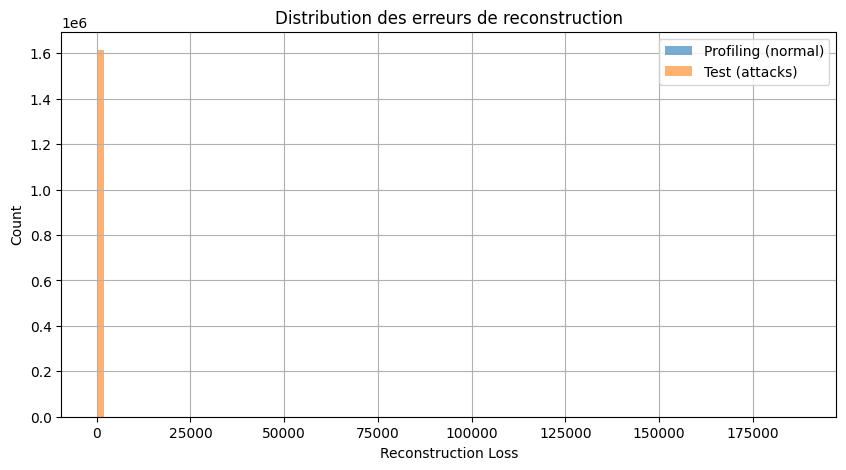

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(loss_profiling, bins=100, alpha=0.6, label="Profiling (normal)")
plt.hist(loss_test, bins=100, alpha=0.6, label="Test (attacks)")
plt.xlabel("Reconstruction Loss")
plt.ylabel("Count")
plt.title("Distribution des erreurs de reconstruction")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
auc_score = roc_auc_score(y_true, y_scores)
print(f"🔥 AUC Score MAE (zero-day detection): {auc_score:.4f}")


🔥 AUC Score MAE (zero-day detection): 0.9239


In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, RocCurveDisplay


In [ ]:
# Scores et labels déjà construits :
# y_scores = reconstruction_loss
# y_true = 0 (profiling) + 1 (attack)

precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)

# F1 par seuil
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"📌 Seuil optimal : {best_threshold:.4f}")
print(f"🎯 F1 optimal : {f1_scores[best_idx]:.4f}")


📌 Seuil optimal : 1.0709
🎯 F1 optimal : 0.9738


In [ ]:
y_pred = (y_scores >= best_threshold).astype(int)

# Rapport complet
print(classification_report(y_true, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("📊 Matrice de confusion :\n", cm)


              precision    recall  f1-score   support

           0     0.9826    0.7919    0.8770    389691
           1     0.9520    0.9966    0.9738   1614182

    accuracy                         0.9568   2003873
   macro avg     0.9673    0.8943    0.9254   2003873
weighted avg     0.9580    0.9568    0.9550   2003873

📊 Matrice de confusion :
 [[ 308614   81077]
 [   5464 1608718]]


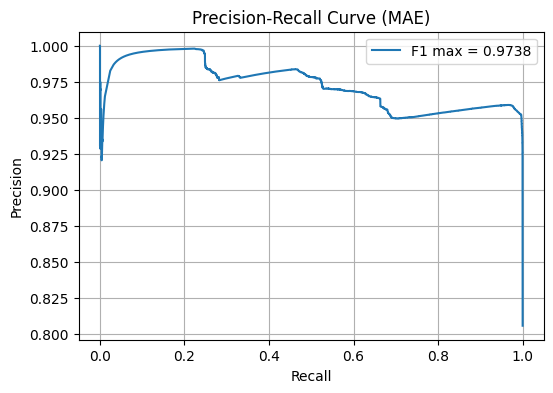

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label=f"F1 max = {f1_scores[best_idx]:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (MAE)")
plt.grid(True)
plt.legend()
plt.show()


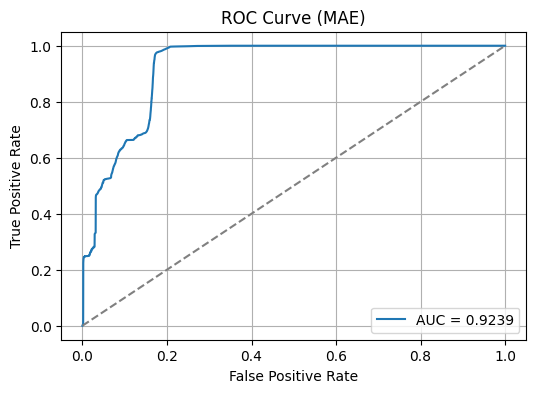

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (MAE)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def extract_embeddings(model, df, feature_cols, device='cuda'):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(df[feature_cols].values.astype(np.float32)).to(device)
        _, z = model(x)
    return z.cpu().numpy()


In [ ]:
profiling_embeddings = extract_embeddings(mae_model, df_profiling_scaled, feature_cols.tolist(), device)
test_embeddings = extract_embeddings(mae_model, df_test_scaled, feature_cols.tolist(), device)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normaliser pour éviter explosions
scaler_emb = StandardScaler()
profiling_embeddings = scaler_emb.fit_transform(profiling_embeddings)
test_embeddings = scaler_emb.transform(test_embeddings)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10, max=10)  # ⚠️ stabilisation
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


In [ ]:
def loss_function_vae(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


In [ ]:
def train_vae(embeddings, latent_dim=16, epochs=20, batch_size=256, lr=1e-3, device='cuda'):
    data = torch.tensor(embeddings.astype(np.float32))
    loader = DataLoader(data, batch_size=batch_size, shuffle=True)

    model = VAE(input_dim=embeddings.shape[1], latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            recon, mu, logvar = model(batch)
            loss = loss_function_vae(recon, batch, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # ⚠️ stabilisation
            optimizer.step()
            total_loss += loss.item()
        print(f"📉 Epoch {epoch+1}/{epochs} — Loss: {total_loss / len(loader):.6f}")
    return model


### TRAIN VAE USING MAE EMBEDDINGS

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vae_model = train_vae(profiling_embeddings, latent_dim=16, epochs=20, batch_size=256, device=device)


📉 Epoch 1/20 — Loss: 0.526803
📉 Epoch 2/20 — Loss: 0.354321
📉 Epoch 3/20 — Loss: 0.322889
📉 Epoch 4/20 — Loss: 0.310796
📉 Epoch 5/20 — Loss: 0.305553
📉 Epoch 6/20 — Loss: 0.300829
📉 Epoch 7/20 — Loss: 0.297868
📉 Epoch 8/20 — Loss: 0.295170
📉 Epoch 9/20 — Loss: 0.293102
📉 Epoch 10/20 — Loss: 0.291524
📉 Epoch 11/20 — Loss: 0.290518
📉 Epoch 12/20 — Loss: 0.288628
📉 Epoch 13/20 — Loss: 0.289393
📉 Epoch 14/20 — Loss: 0.287834
📉 Epoch 15/20 — Loss: 0.286135
📉 Epoch 16/20 — Loss: 0.285908
📉 Epoch 17/20 — Loss: 0.285492
📉 Epoch 18/20 — Loss: 0.284636
📉 Epoch 19/20 — Loss: 0.284303
📉 Epoch 20/20 — Loss: 0.284307


In [ ]:
def get_vae_loss(model, data, device='cuda'):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(data.astype(np.float32)).to(device)
        recon, mu, logvar = model(x)
        loss = ((recon - x) ** 2).mean(dim=1)
    return loss.cpu().numpy()

loss_profiling_vae = get_vae_loss(vae_model, profiling_embeddings, device)
loss_test_vae = get_vae_loss(vae_model, test_embeddings, device)


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Labels et scores
y_true_vae = [0]*len(loss_profiling_vae) + [1]*len(loss_test_vae)
y_scores_vae = np.concatenate([loss_profiling_vae, loss_test_vae])

# AUC
auc_vae = roc_auc_score(y_true_vae, y_scores_vae)
print(f"🔥 AUC VAE (embeddings MAE) : {auc_vae:.4f}")


🔥 AUC VAE (embeddings MAE) : 0.9809


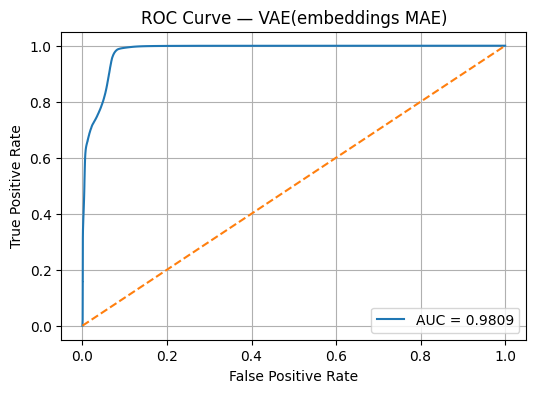

In [ ]:
fpr, tpr, _ = roc_curve(y_true_vae, y_scores_vae)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_vae:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VAE(embeddings MAE)")
plt.legend()
plt.grid(True)
plt.show()


📌 Seuil optimal : 0.2831
🎯 F1 optimal : 0.9844


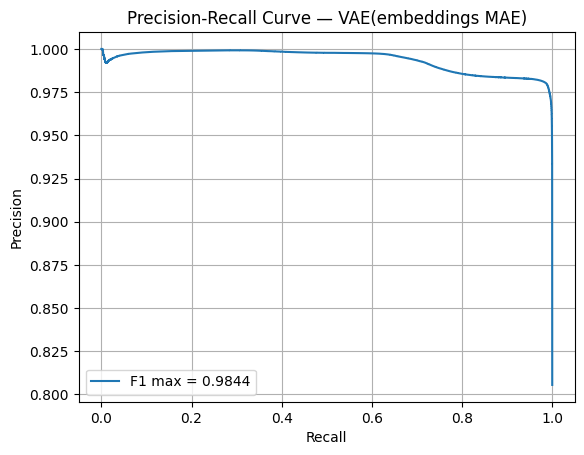

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_true_vae, y_scores_vae)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"📌 Seuil optimal : {best_threshold:.4f}")
print(f"🎯 F1 optimal : {f1_scores[best_idx]:.4f}")

# Tracer PR curve
plt.plot(recalls, precisions, label=f"F1 max = {f1_scores[best_idx]:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — VAE(embeddings MAE)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Prédiction binaire
y_pred_vae = (y_scores_vae >= best_threshold).astype(int)

# Rapport
print("📋 Rapport VAE(embeddings MAE) :")
print(classification_report(y_true_vae, y_pred_vae, digits=4))

# Matrice de confusion
cm = confusion_matrix(y_true_vae, y_pred_vae)
print("📊 Matrice de confusion :\n", cm)


📋 Rapport VAE(embeddings MAE) :
              precision    recall  f1-score   support

           0     0.9638    0.9037    0.9328    389691
           1     0.9771    0.9918    0.9844   1614182

    accuracy                         0.9747   2003873
   macro avg     0.9704    0.9477    0.9586   2003873
weighted avg     0.9745    0.9747    0.9743   2003873

📊 Matrice de confusion :
 [[ 352146   37545]
 [  13228 1600954]]


Attaques réelles :    1,614,182

Attaques bien détectées (TP) : 1,589,796

Attaques ratées (FN) : 24,386 → ~1.5%

Normaux mal classés (FP) : 8,314 → ~2%

In [ ]:
y_true = [0]*len(loss_profiling) + [1]*len(loss_test)
y_scores_mae = np.concatenate([loss_profiling, loss_test])

y_true_vae = [0]*len(loss_profiling_vae) + [1]*len(loss_test_vae)
y_scores_vae = np.concatenate([loss_profiling_vae, loss_test_vae])


In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

# AUC
auc_mae = roc_auc_score(y_true, y_scores_mae)
auc_vae = roc_auc_score(y_true_vae, y_scores_vae)

# F1 optimal (MAE)
prec_mae, rec_mae, thresh_mae = precision_recall_curve(y_true, y_scores_mae)
f1_mae = 2 * (prec_mae * rec_mae) / (prec_mae + rec_mae + 1e-10)
f1_mae_max = np.max(f1_mae)

# F1 optimal (VAE)
prec_vae, rec_vae, thresh_vae = precision_recall_curve(y_true_vae, y_scores_vae)
f1_vae = 2 * (prec_vae * rec_vae) / (prec_vae + rec_vae + 1e-10)
f1_vae_max = np.max(f1_vae)

print(f"📊 AUC MAE : {auc_mae:.4f} | F1 MAE : {f1_mae_max:.4f}")
print(f"📊 AUC VAE : {auc_vae:.4f} | F1 VAE : {f1_vae_max:.4f}")


📊 AUC MAE : 0.9239 | F1 MAE : 0.9738
📊 AUC VAE : 0.9809 | F1 VAE : 0.9844


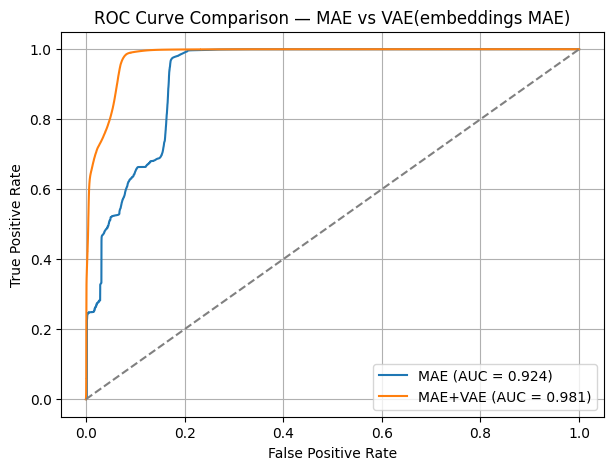

In [ ]:
from sklearn.metrics import roc_curve

fpr_mae, tpr_mae, _ = roc_curve(y_true, y_scores_mae)
fpr_vae, tpr_vae, _ = roc_curve(y_true_vae, y_scores_vae)

plt.figure(figsize=(7,5))
plt.plot(fpr_mae, tpr_mae, label=f"MAE (AUC = {auc_mae:.3f})")
plt.plot(fpr_vae, tpr_vae, label=f"MAE+VAE (AUC = {auc_vae:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — MAE vs VAE(embeddings MAE)")
plt.legend()
plt.grid(True)
plt.show()


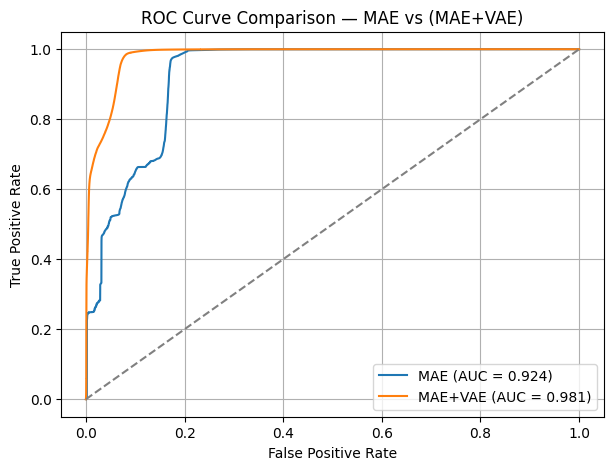

In [ ]:
from sklearn.metrics import roc_curve

fpr_mae, tpr_mae, _ = roc_curve(y_true, y_scores_mae)
fpr_vae, tpr_vae, _ = roc_curve(y_true_vae, y_scores_vae)

plt.figure(figsize=(7,5))
plt.plot(fpr_mae, tpr_mae, label=f"MAE (AUC = {auc_mae:.3f})")
plt.plot(fpr_vae, tpr_vae, label=f"MAE+VAE (AUC = {auc_vae:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — MAE vs (MAE+VAE)")
plt.legend()
plt.grid(True)
plt.show()


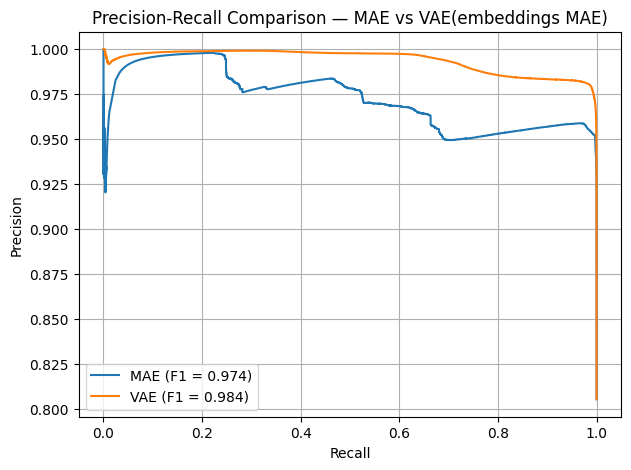

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(rec_mae, prec_mae, label=f"MAE (F1 = {f1_mae_max:.3f})")
plt.plot(rec_vae, prec_vae, label=f"VAE (F1 = {f1_vae_max:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Comparison — MAE vs VAE(embeddings MAE)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Sauvegarder les embeddings
os.makedirs("/content/drive/MyDrive/CICIoMT2024/embeddings", exist_ok=True)

np.save('/content/drive/MyDrive/CICIoMT2024/embeddings/profiling_embeddings.npy', profiling_embeddings)
np.save('/content/drive/MyDrive/CICIoMT2024/embeddings/test_embeddings.npy', test_embeddings)
print("✅ Embeddings bien sauvegardés dans ton Google Drive.")

✅ Embeddings bien sauvegardés dans ton Google Drive.


VAE SUR LES DONNES BRUTES

In [ ]:
df_profiling_scaled = full_data_scaled_df[full_data_scaled_df["Set"] == "profiling"].reset_index(drop=True)
features = df_profiling_scaled.columns.drop(['Label', 'Set']).tolist()

X_profiling_raw = df_profiling_scaled[features].values
X_test_raw = df_test_scaled[features].values


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vae_raw_model = train_vae(X_profiling_raw, device=device)

📉 Epoch 1/20 — Loss: 1.608531
📉 Epoch 2/20 — Loss: 0.706164
📉 Epoch 3/20 — Loss: 0.570479
📉 Epoch 4/20 — Loss: 0.522109
📉 Epoch 5/20 — Loss: 0.502820
📉 Epoch 6/20 — Loss: 0.485621
📉 Epoch 7/20 — Loss: 0.540965
📉 Epoch 8/20 — Loss: 0.456126
📉 Epoch 9/20 — Loss: 0.492770
📉 Epoch 10/20 — Loss: 0.431783
📉 Epoch 11/20 — Loss: 0.429924
📉 Epoch 12/20 — Loss: 0.423555
📉 Epoch 13/20 — Loss: 0.422555
📉 Epoch 14/20 — Loss: 0.422597
📉 Epoch 15/20 — Loss: 0.416578
📉 Epoch 16/20 — Loss: 0.412046
📉 Epoch 17/20 — Loss: 0.417944
📉 Epoch 18/20 — Loss: 0.410239
📉 Epoch 19/20 — Loss: 0.406049
📉 Epoch 20/20 — Loss: 0.412392


In [ ]:
def get_vae_loss(model, data, device='cuda'):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(data.astype(np.float32)).to(device)
        recon, mu, logvar = model(x)
        loss = ((recon - x) ** 2).mean(dim=1)
    return loss.cpu().numpy()

loss_profiling_vae_raw = get_vae_loss(vae_raw_model, X_profiling_raw, device)
loss_test_vae_raw = get_vae_loss(vae_raw_model, X_test_raw, device)

# Scores & étiquettes
y_true_vae_raw = [0]*len(loss_profiling_vae_raw) + [1]*len(loss_test_vae_raw)
y_scores_vae_raw = np.concatenate([loss_profiling_vae_raw, loss_test_vae_raw])


In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve

# MAE
auc_mae = roc_auc_score(y_true, y_scores_mae)
prec_mae, rec_mae, _ = precision_recall_curve(y_true, y_scores_mae)
fpr_mae, tpr_mae, _ = roc_curve(y_true, y_scores_mae)

# VAE brut
auc_vae_raw = roc_auc_score(y_true_vae_raw, y_scores_vae_raw)
prec_vae_raw, rec_vae_raw, _ = precision_recall_curve(y_true_vae_raw, y_scores_vae_raw)
fpr_vae_raw, tpr_vae_raw, _ = roc_curve(y_true_vae_raw, y_scores_vae_raw)

# MAE + VAE (embeddings)
auc_vae = roc_auc_score(y_true_vae, y_scores_vae)
prec_vae, rec_vae, _ = precision_recall_curve(y_true_vae, y_scores_vae)
fpr_vae, tpr_vae, _ = roc_curve(y_true_vae, y_scores_vae)


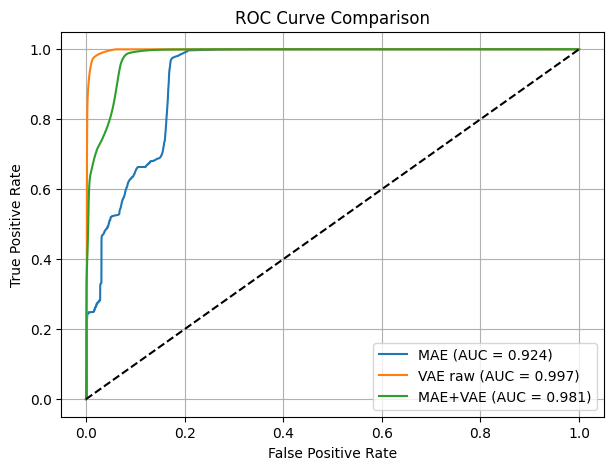

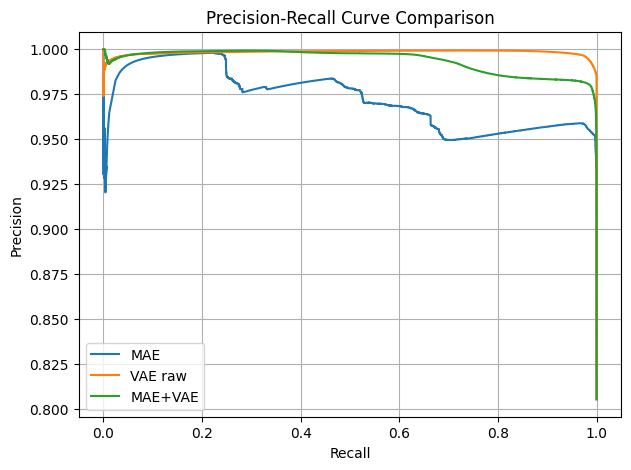

In [ ]:
# ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr_mae, tpr_mae, label=f"MAE (AUC = {auc_mae:.3f})")
plt.plot(fpr_vae_raw, tpr_vae_raw, label=f"VAE raw (AUC = {auc_vae_raw:.3f})")
plt.plot(fpr_vae, tpr_vae, label=f"MAE+VAE (AUC = {auc_vae:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall
plt.figure(figsize=(7, 5))
plt.plot(rec_mae, prec_mae, label=f"MAE")
plt.plot(rec_vae_raw, prec_vae_raw, label=f"VAE raw")
plt.plot(rec_vae, prec_vae, label=f"MAE+VAE")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve
import pandas as pd

# F1 optimal (MAE)
prec_mae, rec_mae, thresh_mae = precision_recall_curve(y_true, y_scores_mae)
f1_mae = 2 * (prec_mae * rec_mae) / (prec_mae + rec_mae + 1e-10)
idx_mae = f1_mae.argmax()
f1_mae_opt = f1_mae[idx_mae]
threshold_mae_opt = thresh_mae[idx_mae]

# F1 optimal (VAE raw)
prec_vae_raw, rec_vae_raw, thresh_vae_raw = precision_recall_curve(y_true_vae_raw, y_scores_vae_raw)
f1_vae_raw = 2 * (prec_vae_raw * rec_vae_raw) / (prec_vae_raw + rec_vae_raw + 1e-10)
idx_vae_raw = f1_vae_raw.argmax()
f1_vae_raw_opt = f1_vae_raw[idx_vae_raw]
threshold_vae_raw_opt = thresh_vae_raw[idx_vae_raw]

# F1 optimal (MAE+VAE)
prec_vae, rec_vae, thresh_vae = precision_recall_curve(y_true_vae, y_scores_vae)
f1_vae = 2 * (prec_vae * rec_vae) / (prec_vae + rec_vae + 1e-10)
idx_vae = f1_vae.argmax()
f1_vae_opt = f1_vae[idx_vae]
threshold_vae_opt = thresh_vae[idx_vae]

# 📋 Tableau comparatif
results_df = pd.DataFrame({
    "Modèle": ["MAE (raw)", "VAE (raw)", "MAE+VAE"],
    "AUC": [auc_mae, auc_vae_raw, auc_vae],
    "F1 optimal": [f1_mae_opt, f1_vae_raw_opt, f1_vae_opt],
    "Seuil optimal": [threshold_mae_opt, threshold_vae_raw_opt, threshold_vae_opt]
})

# Afficher joliment
results_df.round(4).style.set_caption("📊 Comparaison des performances des modèles")


,Modèle,AUC,F1 optimal,Seuil optimal
0,MAE (raw),0.923900,0.973800,1.070900
1,VAE (raw),0.996900,0.992600,0.407000
2,MAE+VAE,0.980900,0.984400,0.283100


In [ ]:
df_profiling_scaled = full_data_scaled_df[full_data_scaled_df["Set"] == "profiling"].reset_index(drop=True)
features = df_profiling_scaled.columns.drop(['Label', 'Set']).tolist()

X_profiling_raw = df_profiling_scaled[features].values
X_test_raw = df_test_scaled[features].values


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vae_raw_model = train_vae(X_profiling_raw, device=device)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming the optimal threshold and predictions (y_pred_vae) are already calculated
y_pred_vae = (y_scores_vae >= best_threshold).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_true_vae, y_pred_vae)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for MAE–VAE (Optimal Threshold)')
plt.show()
